# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.2

NGSOLVE = True

lc = 0.6

from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
# mesh = CleanCircle(R=R, verbosity=0, lc=lc)


In [2]:
mesh.n_triangles

99

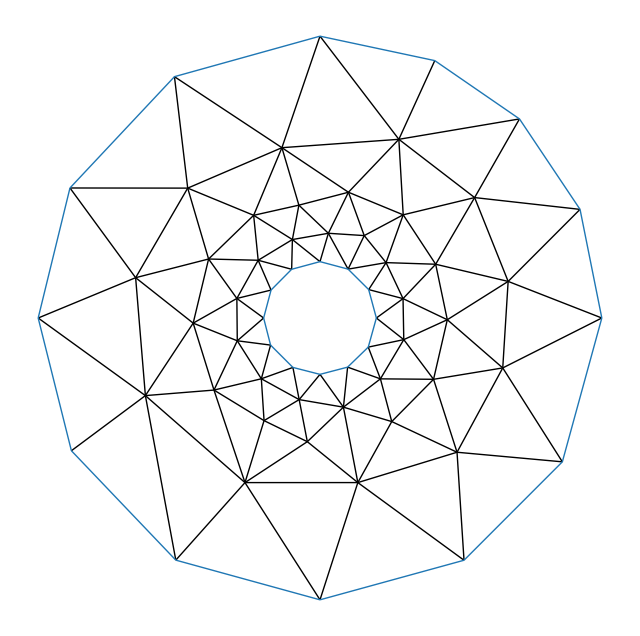

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
mesh.curve_region(Regions.d_Omega, radius=r)


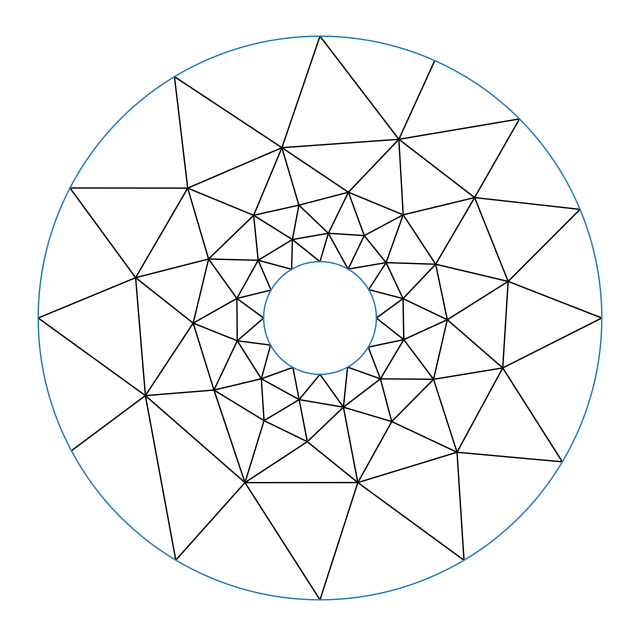

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = {"d_inc": np.array([-1., 0.])}
data = PlaneWave(d=np.array([-1., 0.]), A=-1.)
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
# from trefftz.dg.assemblers import SerialNumerics
# NtD_modes = 15
# a = 0.5
# b = 0.5
# d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

In [12]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 20
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [ ]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 16.0
Ntheta = 15
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [14]:
basis.N_DOF

1980

In [15]:
# from trefftz.dg.assemblers import SerialAssembler

# assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [16]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [17]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [18]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


  0%|          | 0/13 [00:00<?, ?edge/s]

100%|██████████| 13/13 [00:02<00:00,  6.47edge/s]


region: d_Omega


Interior: 100%|██████████| 136/136 [00:00<00:00, 1049.95edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 13/13 [01:31<00:00,  7.05s/edge]


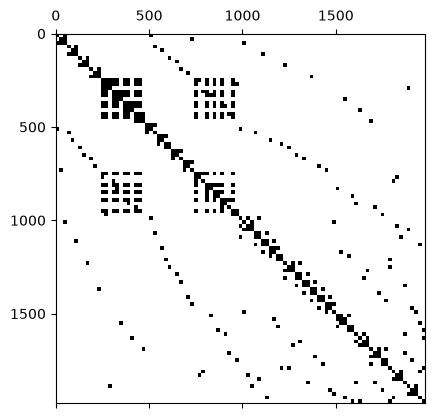

In [19]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [20]:
b = P.assemble_RHS()

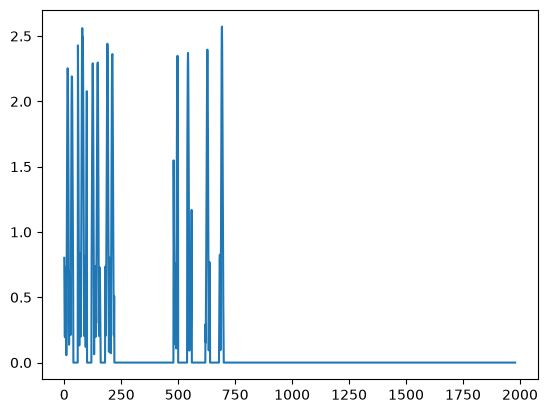

In [21]:
import numpy as np 
plt.plot(np.abs(b))

In [22]:
P.solve()

In [23]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-9.27280864e+03-2.79045945e+04j, -2.16487619e+04+2.09369992e+04j,
         2.84262349e+04+9.56514402e+03j, ...,
         1.03362307e+04-2.01059473e+04j, -2.12532468e+04+1.42279566e+04j,
         2.71805200e+04+6.18042095e+03j],
       [-9.29839808e+03+4.21422478e+02j,  5.69900948e+03+5.83188652e+03j,
        -1.11401680e+03-6.96291951e+03j, ...,
        -1.16090112e+04-2.42631856e+03j,  4.94462395e+03+1.01731252e+04j,
         5.43147622e+03-8.88454942e+03j],
       [-3.86107289e+03-3.76063293e+03j, -2.60503615e+03+4.60541101e+03j,
         5.12716055e+03+6.45040921e+02j, ...,
        -4.68552790e+03-2.26590447e+03j,  8.89045251e+02+5.29081482e+03j,
         4.63944463e+03-2.81050450e+03j],
       ...,
       [-2.74675578e+00-2.09904125e+00j, -3.40599306e+00+1.22635038e+00j,
         8.51748917e-01+3.57539166e+00j, ...,
         2.92177170e+00-1.80133000e-01j,  1.63221171e+00-2.59881604e+00j,
        -5.51311847e-01-3.20585691e+00j],
       [ 1.10091178e+01+8.86796573e+00j,  2.

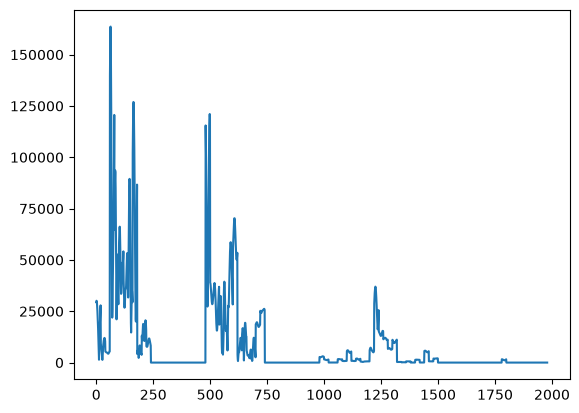

In [24]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [25]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [26]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

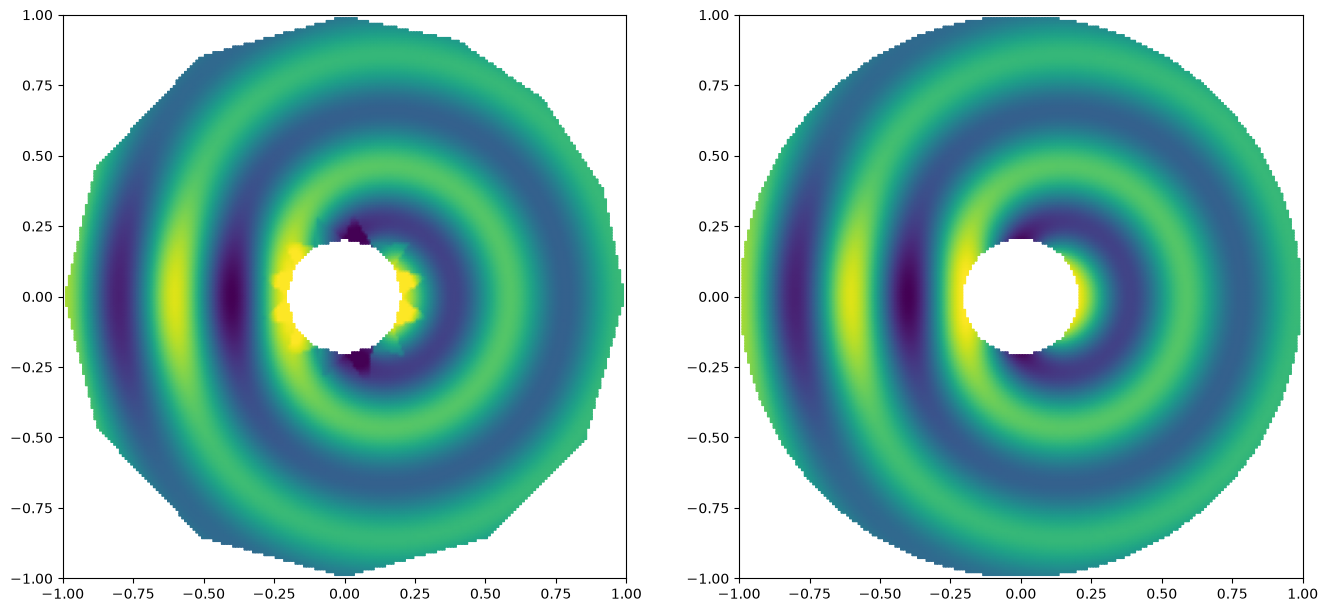

In [29]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

RHO = np.sqrt(X**2 + Y**2)
THETA = np.arctan2(Y,X)
from scipy.special import jn, hankel1

Z_exact = -sum( 1j**n*jn(n, k*r)*hankel1(n, k*RHO)/hankel1(n, k*r)*np.exp(1j*n*(THETA-np.pi)) for n in range(-50,51))
Z_exact[RHO < r ] = np.nan
Z_exact[RHO > R ] = np.nan

import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), vmin=-1, vmax=1, shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')

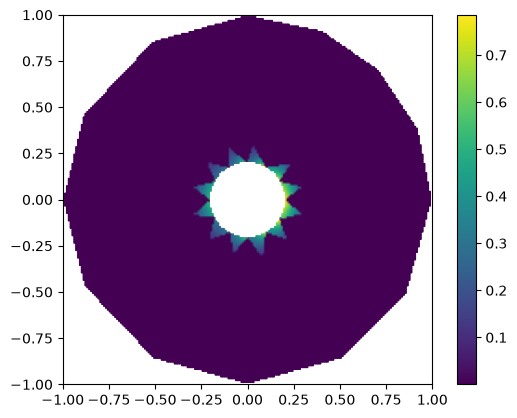

In [30]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()